In [ ]:
#Duration of unemployment
#url = 'https://data.ontario.ca/dataset/4edcd678-6f24-4064-970b-b7254fc6671e/resource/8f786bb5-01ac-4e7d-b89f-3437a601941b/download/mltsd_v0906_18_tab2qq.csv


In [1]:
#load the libs
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
# Load the CSV file
url = "c:/Users/User/DSI/visualization/02_activities/assignments/Duration of unemployment.csv"
df = pd.read_csv(url)
df

,_id,MONTH,GEOGRAPHY,DURATION,AGE GROUP,Both sexes,Male,Female
0,1,Mar2001,"Total, Ontario regions",Total unemployed,"Total, 15 years and over",398.0,229.0,169.0
1,2,Mar2001,"Total, Ontario regions",Total unemployed,15-64 years,395.8,228.0,167.9
2,3,Mar2001,"Total, Ontario regions",Total unemployed,15-19,67.5,39.3,28.1
3,4,Mar2001,"Total, Ontario regions",Total unemployed,20-24,53.9,36.2,17.7
4,5,Mar2001,"Total, Ontario regions",Total unemployed,25-44,184.4,101.7,82.7
...,...,...,...,...,...,...,...,...
37915,37916,Sep2020,Northern region,Average weeks unemployed (top-code = 99 weeks),20-24,16.8,20.6,11.8
37916,37917,Sep2020,Northern region,Average weeks unemployed (top-code = 99 weeks),25-44,14.5,16.9,10.6
37917,37918,Sep2020,Northern region,Average weeks unemployed (top-code = 99 weeks),45-54,17.4,19.9,16.1
37918,37919,Sep2020,Northern region,Average weeks unemployed (top-code = 99 weeks),55-64,28.7,32.4,22.5


In [4]:
# Load data and rename columns
columns = ['id','date', 'geography', 'duration', 'agegroup', 'bothgenders', 'male', 'female' ]
df_dd = (pd.read_csv(url, header = 0, names = columns))

df_dd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37920 entries, 0 to 37919
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           37920 non-null  int64  
 1   date         37920 non-null  object 
 2   geography    37920 non-null  object 
 3   duration     37920 non-null  object 
 4   agegroup     37920 non-null  object 
 5   bothgenders  37920 non-null  float64
 6   male         37920 non-null  float64
 7   female       37920 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 2.3+ MB


In [5]:
#reformat date column  from object to datetime
df_dd['date'] = pd.to_datetime(df_dd['date'], format="%b%Y")
df_dd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37920 entries, 0 to 37919
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           37920 non-null  int64         
 1   date         37920 non-null  datetime64[ns]
 2   geography    37920 non-null  object        
 3   duration     37920 non-null  object        
 4   agegroup     37920 non-null  object        
 5   bothgenders  37920 non-null  float64       
 6   male         37920 non-null  float64       
 7   female       37920 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 2.3+ MB


In [6]:
#drop column id as not used
df_dt = df_dd.drop(columns = ["id"])
# Extract the year and ensure it's an integer
df_dt['year'] = df_dt['date'].apply(lambda x: int(pd.to_datetime(x, format='%b%Y').year))
df_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37920 entries, 0 to 37919
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         37920 non-null  datetime64[ns]
 1   geography    37920 non-null  object        
 2   duration     37920 non-null  object        
 3   agegroup     37920 non-null  object        
 4   bothgenders  37920 non-null  float64       
 5   male         37920 non-null  float64       
 6   female       37920 non-null  float64       
 7   year         37920 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 2.3+ MB


In [7]:
# Set plot 
sns.set(style="darkgrid")
# Set plot style
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})

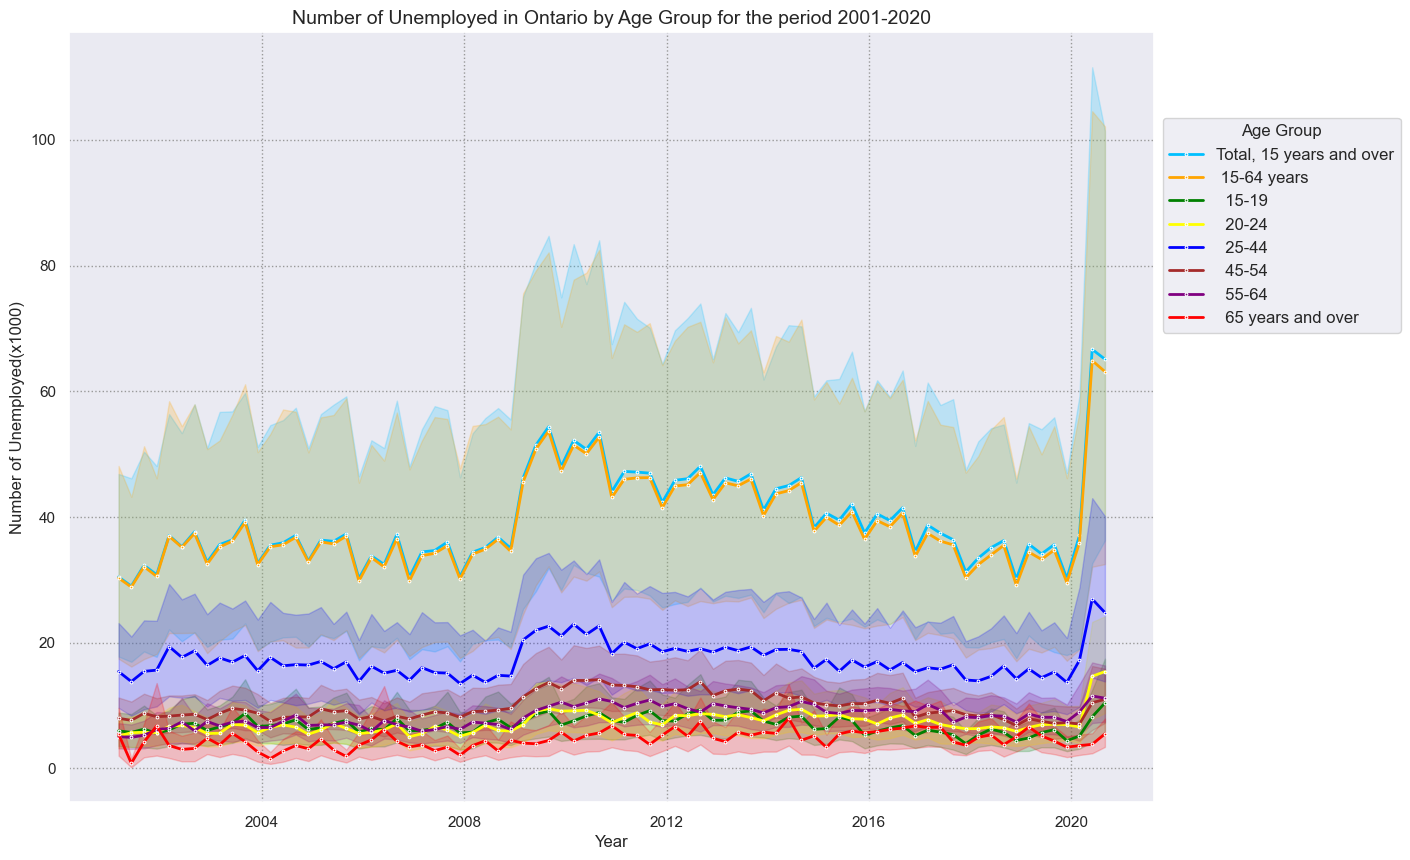

In [8]:
#create the lineplot
plt.figure(figsize=(14,10) )

sns.lineplot(x = 'date', y='bothgenders',data= df_dt, linewidth=2, hue='agegroup', palette=['deepskyblue', 'orange', 'green', 'yellow', 'blue','brown','purple', 'red'], marker = 'o', markersize = 2)# palette =   ['brown', 'blue', 'deepskyblue', 'orange', 'grey', 'yellow', 'blue','yellowgreen'])#'skyblue', 'broun','yellowgreen'])##['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

# Add titles and labels
plt.title('Number of Unemployed in Ontario by Age Group for the period 2001-2020', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Unemployed(x1000)', fontsize=12)


# Move the legend outside of the plot
plt.legend(title='Age Group', bbox_to_anchor=(1.0, 0.9), loc='upper left', fontsize=12)